# Clustering por densidad: DBSCAN y HDBSCAN

> Cómo agrupar datos buscando las zonas densas separadas por huecos: sin fijar el número de grupos, con formas arbitrarias y marcando el ruido. Se explican DBSCAN, su extensión jerárquica HDBSCAN y cómo evaluar un agrupamiento que deja puntos sin asignar.
>
> **Requisitos previos:** [k-means y derivados](05-kmeans-y-derivados.ipynb) · [distancias y escalado](../03-preparacion-datos/05-distancias-y-similitud.ipynb) · **Relacionado:** [clustering jerárquico](04-clustering-jerarquico.ipynb) · [reducción de dimensionalidad](02-reduccion-dimensionalidad.ipynb)

## 1. Idea clave

Un método **por densidad** entiende un grupo como una región donde los puntos están muy juntos, separada de otras regiones por zonas casi vacías. De ahí salen tres ventajas frente a k-means: **no hace falta fijar el número de grupos**, los grupos pueden tener **cualquier forma** (lunas, anillos, ramas alargadas) y los puntos que no caen en ninguna región densa se marcan como **ruido** (etiqueta `-1`) en lugar de forzarlos a un grupo.

**DBSCAN** usa un único umbral de densidad (un radio $\varepsilon$ y un mínimo de vecinos), así que le cuesta cuando los grupos tienen densidades muy distintas. **HDBSCAN** lo repite para todos los radios a la vez y se queda con los grupos más estables, por lo que tolera densidades variables y solo necesita un tamaño mínimo de grupo.

Úsalos con pocas dimensiones (o tras reducirlas), formas irregulares, ruido o un $k$ desconocido. Evítalos si los grupos se solapan sin huecos entre ellos, si hay decenas de dimensiones sin reducir, o si necesitas que **todos** los puntos tengan grupo.

## 2. Conceptos importantes

### 2.1. DBSCAN: núcleos, bordes y ruido

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) tiene dos parámetros: un radio $\varepsilon$ y un número mínimo de puntos `min_samples` (en la teoría, *minPts*). La **vecindad** de un punto $\mathbf{x}$ son todos los puntos a distancia como mucho $\varepsilon$ de él (incluido él mismo):

$$
N_\varepsilon(\mathbf{x}) = \{\mathbf{y} \in D : d(\mathbf{x}, \mathbf{y}) \le \varepsilon\}
$$

Con ella, cada punto es de uno de tres tipos:

- **Núcleo** (*core*): su vecindad tiene al menos `min_samples` puntos, $|N_\varepsilon(\mathbf{x})| \ge$ `min_samples`. Está en una zona densa.
- **Borde** (*border*): no es núcleo, pero está en la vecindad de algún núcleo. Está en la frontera de un grupo.
- **Ruido** (*noise*): no es ni núcleo ni borde.

Un **grupo** es un conjunto de núcleos conectados entre sí (cada uno a distancia $\le \varepsilon$ de otro del conjunto, formando una cadena) más los bordes que cuelgan de ellos. El algoritmo es simple: toma un punto sin visitar, y si es núcleo, abre un grupo y lo va **expandiendo** a través de los núcleos vecinos; si no, lo deja provisionalmente como ruido (un borde puede recuperarse después al expandir un grupo vecino).

Es determinista salvo en un detalle: un borde alcanzable desde dos grupos se queda con el primero que lo alcance, así que puede depender del orden de los datos. Los núcleos y el ruido no dependen del orden.

### 2.2. Elegir $\varepsilon$ y `min_samples`

- **`min_samples`**: sube con la dimensión y con el ruido. Una regla práctica es partir de un valor algo mayor que el número de dimensiones (en 2D, entre 4 y 10). Valores mayores hacen el método más estricto: más ruido y menos grupos pequeños.
- **$\varepsilon$**: se suele elegir con el **gráfico de $k$-distancia**. Para cada punto se calcula la distancia a su $k$-ésimo vecino más cercano, con $k$ = `min_samples`, y se ordenan de menor a mayor. Los puntos de las zonas densas dan distancias pequeñas, y los aislados, distancias grandes: el **codo** de la curva separa unos de otros y su altura es un buen candidato para $\varepsilon$.

Como $\varepsilon$ es una distancia, **depende de la escala** de los datos: hay que [estandarizar](../03-preparacion-datos/05-distancias-y-similitud.ipynb) antes.

### 2.3. El límite de DBSCAN: una sola densidad

Un único $\varepsilon$ define un único nivel de densidad. Si un grupo es denso y otro es disperso, un $\varepsilon$ pequeño deja al disperso convertido en ruido, y un $\varepsilon$ grande funde los grupos densos que estén próximos. Esto es lo que resuelve HDBSCAN.

### 2.4. HDBSCAN: todos los $\varepsilon$ a la vez

HDBSCAN (*Hierarchical DBSCAN*) sustituye el radio fijo por una jerarquía de densidades y elige los grupos más estables. Los pasos son:

1. **Distancia núcleo.** Para cada punto, $d_\text{núcleo}(\mathbf{x})$ es la distancia a su `min_samples`-ésimo vecino (contándose a sí mismo). Es grande en zonas dispersas y pequeña en zonas densas.
2. **Distancia de alcance mutua.** Se "aleja" los puntos poco densos entre sí:

$$
d_\text{alc}(\mathbf{a}, \mathbf{b}) = \max\{\, d_\text{núcleo}(\mathbf{a}),\; d_\text{núcleo}(\mathbf{b}),\; d(\mathbf{a}, \mathbf{b}) \,\}
$$

3. **Jerarquía.** Con esa distancia se construye el árbol de expansión mínimo y, a partir de él, un dendrograma equivalente al del [enlace simple](04-clustering-jerarquico.ipynb). Cortarlo a una altura $\varepsilon$ equivale a ejecutar DBSCAN con ese radio (en su variante DBSCAN\*, que trata los bordes como ruido), para todos los radios a la vez.
4. **Condensar.** Se recorre la jerarquía de arriba abajo. Cuando un grupo se parte en dos, si una rama tiene menos de `min_cluster_size` puntos, se considera que esos puntos simplemente **salen** del grupo (no crean uno nuevo). Solo es una división real si ambas ramas llegan al tamaño mínimo.
5. **Estabilidad.** Con $\lambda = 1/\varepsilon$ (a mayor $\lambda$, más densa la zona), un grupo $C$ nace en $\lambda_\text{nace}(C)$ y cada punto $\mathbf{p}$ sale de él en $\lambda_\mathbf{p}$ (porque deja de ser denso o porque el grupo se divide). Su estabilidad es

$$
S(C) = \sum_{\mathbf{p} \in C} \bigl(\lambda_\mathbf{p} - \lambda_\text{nace}(C)\bigr)
$$

   y mide cuánto "vive" el grupo y con cuántos puntos. El criterio por defecto (`eom`, *excess of mass*) mantiene un grupo si su estabilidad es mayor que la suma de la de sus descendientes. Los puntos que no acaban en ningún grupo seleccionado son **ruido**.

### 2.5. Evaluar un agrupamiento por densidad

Las métricas habituales de k-means asumen grupos compactos, y aquí fallan:

- **Silueta**: compara la cohesión de cada punto con su grupo y la distancia al grupo más cercano. Penaliza los grupos alargados o curvos aunque estén perfectamente separados.
- **Índice de Dunn**: cociente entre la **separación** mínima (distancia más corta entre puntos de grupos distintos) y el **diámetro** máximo (distancia más larga dentro de un mismo grupo):

$$
\text{Dunn} = \frac{\min_{p \ne q}\ \text{sep}(p, q)}{\max_p\ \text{diam}(p)}
$$

  Cuanto mayor, mejores grupos: compactos y bien separados. Se mide solo sobre los puntos que no son ruido.
- **Índice de Rand ajustado (ARI)**: compara con unas etiquetas verdaderas, si las hay. Es la medida más fiable cuando se dispone de ellas.
- **DBCV** (*Density-Based Clustering Validation*): métrica pensada para grupos por densidad. No está en scikit-learn; el paquete independiente `hdbscan` ofrece una aproximación (`relative_validity_`).

Con ruido hay que ser cuidadoso: **informa siempre del porcentaje de puntos sin asignar** junto a cualquier métrica, porque calcularla solo sobre el resto puede dar una falsa sensación de calidad.

## 3. Código

Usamos tres conjuntos: **lunas con ruido** (formas no convexas), tres grupos de **densidades distintas** y los **dígitos escritos a mano** (`load_digits`: 1.797 imágenes de 8×8 píxeles, 10 clases; es una copia del conjunto de prueba de un dataset del repositorio UCI). Las etiquetas solo se usan para evaluar con el índice de Rand ajustado, nunca para agrupar.

In [1]:
import warnings

# Avisos conocidos e inofensivos de tqdm, UMAP (al fijar la semilla) y HDBSCAN (valor futuro de copy)
warnings.filterwarnings("ignore", message=".*IProgress.*")
warnings.filterwarnings("ignore", message=".*n_jobs.*")
warnings.filterwarnings("ignore", message=".*copy.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from scipy.spatial.distance import cdist
from sklearn.cluster import DBSCAN, HDBSCAN, KMeans
from sklearn.datasets import load_digits, make_blobs, make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


def resumen(etiquetas, y_verdadera):
    # Nº de grupos, % de ruido y ARI (el ruido cuenta como un grupo más)
    return {
        "grupos": len(set(etiquetas) - {-1}),
        "ruido (%)": round(float(100 * np.mean(etiquetas == -1)), 1),
        "ARI": round(adjusted_rand_score(y_verdadera, etiquetas), 3),
    }

### 3.1. DBSCAN sobre formas no convexas

Dos lunas más 30 puntos de ruido repartidos al azar. La etiqueta `-1` en `y_lunas` marca ese ruido añadido a mano. Para elegir $\varepsilon$ dibujamos el gráfico de $k$-distancia con $k$ = `min_samples`: `kneighbors` sobre los propios datos cuenta cada punto como su primer vecino, igual que hace DBSCAN con la vecindad.

(530, 2)


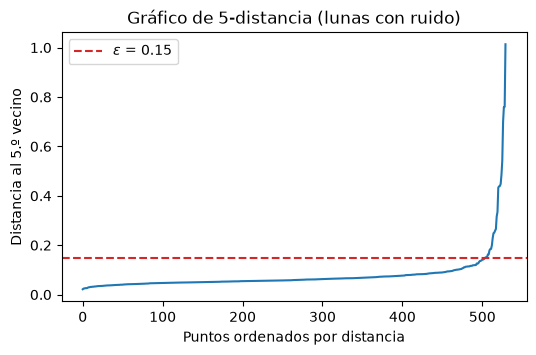

In [2]:
X_lunas, y_lunas = make_moons(n_samples=500, noise=0.06, random_state=42)
rng = np.random.default_rng(42)
ruido_lunas = rng.uniform([-1.5, -1.0], [2.5, 1.5], size=(30, 2))
X_lunas = np.vstack([X_lunas, ruido_lunas])
y_lunas = np.r_[y_lunas, np.full(30, -1)]  # -1: ruido añadido a mano
print(X_lunas.shape)

min_samples = 5
vecinos = NearestNeighbors(n_neighbors=min_samples).fit(X_lunas)
dist_k = np.sort(vecinos.kneighbors(X_lunas)[0][:, -1])

eps = 0.15
plt.figure(figsize=(6, 3.5))
plt.plot(dist_k)
plt.axhline(eps, color="tab:red", linestyle="--", label=f"$\\varepsilon$ = {eps}")
plt.title(f"Gráfico de {min_samples}-distancia (lunas con ruido)")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples}.º vecino")
plt.legend()
plt.show()

La curva sube despacio hasta ≈ 0,1–0,15 y se dispara después: los puntos de la parte alta son los aislados. Tomamos $\varepsilon = 0{,}15$ y comparamos con k-means con $k = 2$.

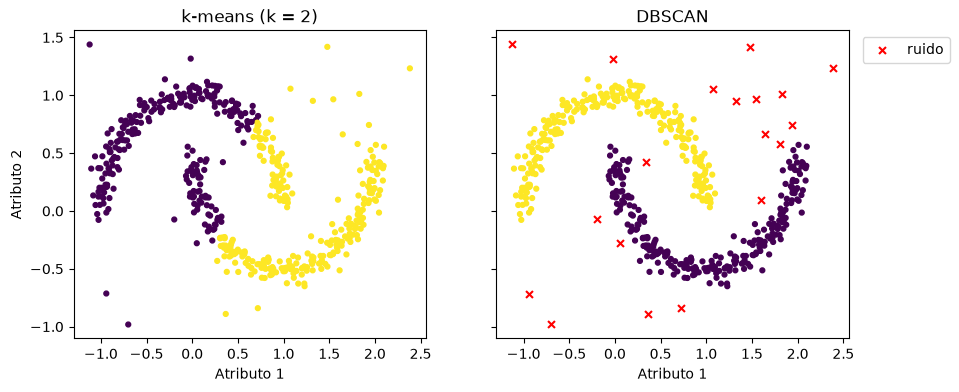

,grupos,ruido (%),ARI
k-means,2,0.0,0.217
DBSCAN,2,3.6,0.957


In [3]:
etiq_dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_lunas)
etiq_kmeans = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_lunas)

fig, ejes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for eje, etiq, titulo in [(ejes[0], etiq_kmeans, "k-means (k = 2)"), (ejes[1], etiq_dbscan, "DBSCAN")]:
    ruido = etiq == -1
    eje.scatter(*X_lunas[~ruido].T, c=etiq[~ruido], cmap="viridis", s=12)
    eje.scatter(*X_lunas[ruido].T, c="red", marker="x", s=25, label="ruido")
    eje.set_title(titulo)
    eje.set_xlabel("Atributo 1")
ejes[0].set_ylabel("Atributo 2")
ejes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

pd.DataFrame.from_dict({"k-means": resumen(etiq_kmeans, y_lunas), "DBSCAN": resumen(etiq_dbscan, y_lunas)}, orient="index")

k-means corta cada luna con una recta y mezcla partes de las dos (ARI bajo). DBSCAN recupera las dos lunas y marca como ruido (cruces rojas) 19 de los 30 puntos aleatorios, sin descartar ningún punto de las lunas. Los otros 11 quedaron dentro de una luna o a menos de $\varepsilon$ de ella y se absorben en su grupo, y por eso el ARI no llega a 1.

### 3.2. Sensibilidad a $\varepsilon$

Con `min_samples` fijo, variamos $\varepsilon$:

In [4]:
barrido = {e: resumen(DBSCAN(eps=e, min_samples=min_samples).fit_predict(X_lunas), y_lunas)
           for e in [0.05, 0.1, 0.15, 0.2, 0.3, 0.5]}
pd.DataFrame.from_dict(barrido, orient="index").rename_axis("eps")

,grupos,ruido (%),ARI
eps,,,
0.05,41,44.7,-0.014
0.10,2,6.0,0.930
0.15,2,3.6,0.957
0.20,2,2.5,0.935
0.30,1,1.7,0.050
0.50,1,0.8,0.022


El rango útil es estrecho. Con $\varepsilon = 0{,}05$ casi la mitad de los puntos quedan como ruido y salen decenas de grupos diminutos. Con $\varepsilon \ge 0{,}3$ las dos lunas se unen en un solo grupo. Entre 0,1 y 0,2 el resultado es estable, y el gráfico de $k$-distancia acierta al apuntar a esa zona. El valor por defecto de scikit-learn (`eps=0.5`) habría fundido todo en un único grupo.

### 3.3. Densidades distintas: DBSCAN frente a HDBSCAN

Dos grupos densos y cercanos, uno disperso y lejano, y 30 puntos de ruido uniforme.

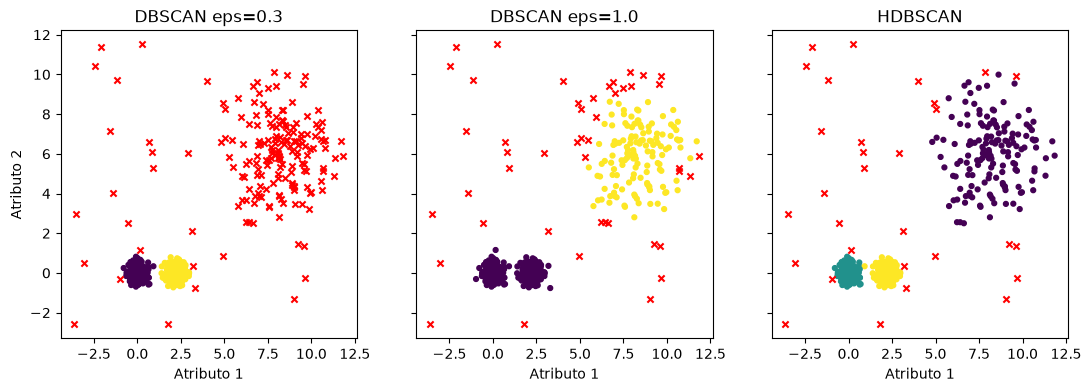

,grupos,ruido (%),ARI
DBSCAN eps=0.3,2,26.8,0.948
DBSCAN eps=1.0,2,6.8,0.446
HDBSCAN,3,4.4,0.969


In [5]:
X_dens, y_dens = make_blobs(n_samples=[250, 250, 150], centers=[[0, 0], [2.2, 0], [8, 6]],
                            cluster_std=[0.3, 0.3, 1.6], random_state=42)
X_dens = np.vstack([X_dens, rng.uniform(-4, 12, size=(30, 2))])
y_dens = np.r_[y_dens, np.full(30, -1)]

modelos_dens = {
    "DBSCAN eps=0.3": DBSCAN(eps=0.3, min_samples=10),
    "DBSCAN eps=1.0": DBSCAN(eps=1.0, min_samples=10),
    "HDBSCAN": HDBSCAN(min_cluster_size=20),
}
etiq_dens = {nombre: modelo.fit_predict(X_dens) for nombre, modelo in modelos_dens.items()}

fig, ejes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for eje, (nombre, etiq) in zip(ejes, etiq_dens.items()):
    ruido = etiq == -1
    eje.scatter(*X_dens[~ruido].T, c=etiq[~ruido], cmap="viridis", s=12)
    eje.scatter(*X_dens[ruido].T, c="red", marker="x", s=20)
    eje.set_title(nombre)
    eje.set_xlabel("Atributo 1")
ejes[0].set_ylabel("Atributo 2")
plt.show()

pd.DataFrame.from_dict({nombre: resumen(etiq, y_dens) for nombre, etiq in etiq_dens.items()}, orient="index")

Con $\varepsilon = 0{,}3$, DBSCAN separa bien los dos grupos densos, pero el grupo disperso entero (sus 150 puntos) queda como ruido. Con $\varepsilon = 1{,}0$ el disperso se recupera, pero los dos densos se funden en uno. **No hay un $\varepsilon$ que funcione para los tres a la vez.** HDBSCAN encuentra los tres con una única configuración, porque evalúa cada región a su propia escala de densidad.

### 3.4. Parámetros de HDBSCAN

Dos parámetros controlan el resultado: `min_cluster_size` (tamaño mínimo para ser un grupo) y `min_samples` (cuántos vecinos se usan para la densidad; si no se indica, vale lo mismo que `min_cluster_size`). Los barremos sobre los mismos datos:

In [6]:
filas = {}
for mcs in [5, 10, 20, 50, 100, 200]:
    filas[("min_cluster_size", mcs)] = resumen(HDBSCAN(min_cluster_size=mcs).fit_predict(X_dens), y_dens)
for ms in [5, 20, 50, 100, 200]:
    filas[("min_samples (con min_cluster_size=50)", ms)] = resumen(
        HDBSCAN(min_cluster_size=50, min_samples=ms).fit_predict(X_dens), y_dens)
pd.DataFrame.from_dict(filas, orient="index")

grupos  ruido (%)    ARI
min_cluster_size                      5         5        7.6  0.877
                                      10        3        3.8  0.975
                                      20        3        4.4  0.969
                                      50        3        6.8  0.952
                                      100       3       11.2  0.910
                                      200       2       32.4  0.790
min_samples (con min_cluster_size=50) 5         3        3.4  0.975
                                      20        3        4.4  0.969
                                      50        3        6.8  0.952
                                      100       3       11.2  0.910
                                      200       2       32.4  0.790

- Con `min_cluster_size` muy bajo (5), los puntos de ruido forman grupos pequeños y aparecen 5 grupos en lugar de 3. Con valores muy altos (200), el grupo de 150 puntos ya no alcanza el tamaño mínimo y desaparece: quedan 2 grupos y casi un tercio de ruido.
- Al subir `min_samples`, el método se vuelve más conservador: **el ruido crece de forma sostenida** (del 3 % al 32 %). Hasta 100 los grupos son los mismos y solo se descartan más puntos de la frontera; con 200 se pierde un grupo entero. Fíjate también en que, por defecto, `min_samples` toma el valor de `min_cluster_size`: por eso las filas de 50, 100 y 200 coinciden en las dos mitades de la tabla, y el ruido depende sobre todo de `min_samples`.

### 3.5. Datos reales: dígitos escritos a mano

Los píxeles ya están en la misma escala (0 a 16), así que no hace falta [estandarizar](../03-preparacion-datos/03-transformacion-datos.ipynb) (hacerlo amplificaría el peso de píxeles casi siempre vacíos). Comparamos HDBSCAN sobre los 64 píxeles originales y sobre una proyección UMAP a 10 y a 2 dimensiones.

In [7]:
X_dig, y_dig = load_digits(return_X_y=True)
print(X_dig.shape)

def proyectar(componentes):
    # min_dist=0 junta los puntos y facilita el clustering posterior
    return umap.UMAP(n_components=componentes, n_neighbors=15, min_dist=0.0, random_state=42).fit_transform(X_dig)

espacios = {"64 píxeles originales": X_dig, "UMAP 10D": proyectar(10), "UMAP 2D": proyectar(2)}
etiq_dig = {nombre: HDBSCAN(min_cluster_size=30).fit_predict(datos) for nombre, datos in espacios.items()}

tabla_dig = pd.DataFrame.from_dict({nombre: resumen(etiq, y_dig) for nombre, etiq in etiq_dig.items()}, orient="index")
# ARI solo sobre los puntos asignados: engañoso si hay mucho ruido
tabla_dig["ARI sin ruido"] = [round(adjusted_rand_score(y_dig[etiq != -1], etiq[etiq != -1]), 3)
                              for etiq in etiq_dig.values()]
tabla_dig

(1797, 64)


,grupos,ruido (%),ARI,ARI sin ruido
64 píxeles originales,7,57.0,0.147,0.900
UMAP 10D,11,2.9,0.908,0.939
UMAP 2D,11,2.1,0.889,0.910


Sobre los **píxeles originales**, HDBSCAN deja más de la mitad de los puntos como ruido y su ARI es bajo. Si se mira solo el ARI de los puntos asignados, parece alto (≈ 0,9), pero es un espejismo: acierta en los pocos puntos que se atreve a asignar. En 64 dimensiones las distancias entre puntos se parecen mucho entre sí (la "maldición de la dimensionalidad") y las regiones densas se difuminan.

Tras reducir con UMAP, casi todos los puntos se asignan a un grupo y el ARI sube a ≈ 0,9. Dibujamos los grupos de la proyección de 10D sobre la de 2D, que usamos **solo para visualizar**:

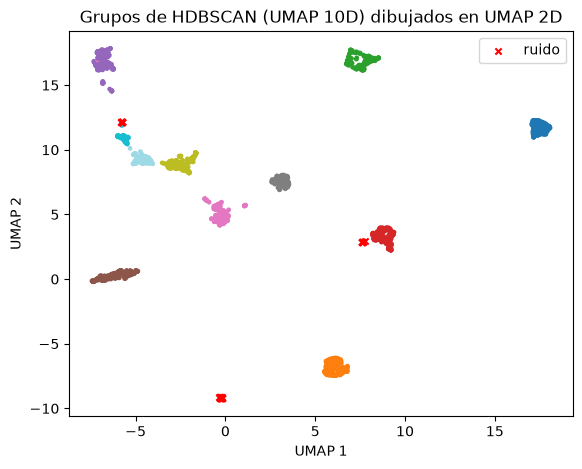

In [8]:
etiq_10d = etiq_dig["UMAP 10D"]
ruido = etiq_10d == -1
plt.figure(figsize=(6.5, 5))
plt.scatter(*espacios["UMAP 2D"][~ruido].T, c=etiq_10d[~ruido], cmap="tab20", s=6)
plt.scatter(*espacios["UMAP 2D"][ruido].T, c="red", marker="x", s=20, label="ruido")
plt.title("Grupos de HDBSCAN (UMAP 10D) dibujados en UMAP 2D")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

### 3.6. Evaluar: silueta, Dunn y ARI

Comparamos k-means y DBSCAN sobre las lunas **sin el ruido añadido**, de modo que ambos agrupen los mismos puntos. Definimos el índice de Dunn de la sección 2.5 y la silueta se calcula solo sobre puntos asignados.

In [9]:
def dunn(X, etiquetas):
    # Separación mínima entre grupos / diámetro máximo dentro de un grupo (sin ruido)
    asignado = etiquetas != -1
    X, etiquetas = X[asignado], etiquetas[asignado]
    grupos = np.unique(etiquetas)
    D = cdist(X, X)
    diametro = max(D[np.ix_(etiquetas == g, etiquetas == g)].max() for g in grupos)
    separacion = min(D[np.ix_(etiquetas == a, etiquetas == b)].min()
                     for a in grupos for b in grupos if a < b)
    return separacion / diametro


X_limpio, y_limpio = X_lunas[y_lunas >= 0], y_lunas[y_lunas >= 0]
candidatos = {
    "k-means": KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_limpio),
    "DBSCAN": DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_limpio),
}
pd.DataFrame.from_dict({
    nombre: {
        "silueta": round(silhouette_score(X_limpio[etiq != -1], etiq[etiq != -1]), 3),
        "Dunn": round(dunn(X_limpio, etiq), 3),
        "ARI": round(adjusted_rand_score(y_limpio, etiq), 3),
        "ruido (%)": round(100 * np.mean(etiq == -1), 1),
    } for nombre, etiq in candidatos.items()
}, orient="index")

,silueta,Dunn,ARI,ruido (%)
k-means,0.488,0.015,0.265,0.0
DBSCAN,0.333,0.157,1.000,0.0


La **silueta prefiere a k-means**, que corta las lunas mal, porque sus dos mitades son compactas. DBSCAN recupera las lunas reales pero obtiene una silueta menor: sus grupos son curvos y alargados. El **índice de Dunn** sí detecta la diferencia, porque k-means deja puntos de grupos distintos casi pegados (separación mínima casi nula). Y el ARI, con las etiquetas verdaderas, lo confirma. Ninguna métrica interna basta sola con formas no convexas: combina Dunn o DBCV, el porcentaje de ruido y, si es posible, una inspección visual o etiquetas de referencia.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `DBSCAN` | `eps` | Radio de la vecindad | Elígelo con el gráfico de $k$-distancia **después de escalar**; el valor por defecto (0,5) rara vez sirve |
| | `min_samples` | Vecinos mínimos para ser núcleo (incluido el propio punto) | Más que el nº de dimensiones; súbelo si hay mucho ruido o grupos solapados |
| | `metric` | Distancia | Euclídea por defecto; `"cosine"` o `"precomputed"` para otros espacios |
| | `algorithm`, `n_jobs` | Búsqueda de vecinos, paralelismo | En pocas dimensiones el índice espacial lo hace eficiente; en muchas, pierde ventaja |
| `HDBSCAN` | `min_cluster_size` | Tamaño mínimo de un grupo | El parámetro principal: ¿cuál es el grupo más pequeño que te interesa? |
| | `min_samples` | Vecinos para la densidad; por defecto igual a `min_cluster_size` | Súbelo para más conservador (más ruido); bájalo para asignar más puntos |
| | `cluster_selection_method` | `"eom"` (por defecto) o `"leaf"` | `"leaf"` da grupos más pequeños y numerosos; `"eom"`, más estables |
| | `cluster_selection_epsilon` | Distancia mínima para fusionar grupos | Útil si salen demasiados grupos pequeños y muy próximos |
| | `allow_single_cluster` | Permite un único grupo | Actívalo si los datos pueden ser un solo grupo; por defecto no se permite |
| | `metric` | Distancia | Igual que en DBSCAN; estandariza antes si es euclídea |
| | `probabilities_` (atributo, no parámetro) | Fuerza de pertenencia de cada punto a su grupo | Úsala para filtrar los puntos dudosos |

### 4.2. Errores comunes

**1. No escalar los atributos.** $\varepsilon$ es una distancia: con un atributo en una escala 100 veces mayor, domina la vecindad. Si estiramos el eje vertical de las lunas ×100, el mismo $\varepsilon$ que funcionaba deja **el 100 % de los puntos como ruido**:

In [10]:
X_estirado = X_limpio * np.array([1, 100])
X_estandarizado = StandardScaler().fit_transform(X_estirado)
for nombre, datos, e in [("estirado sin escalar", X_estirado, 0.15), ("estandarizado", X_estandarizado, 0.3)]:
    print(f"{nombre:22s} eps={e}", resumen(DBSCAN(eps=e, min_samples=5).fit_predict(datos), y_limpio))

estirado sin escalar   eps=0.15 {'grupos': 0, 'ruido (%)': 100.0, 'ARI': 0.0}
estandarizado          eps=0.3 {'grupos': 2, 'ruido (%)': 0.0, 'ARI': 1.0}


Al estandarizar, el $\varepsilon$ hay que **reelegirlo** (la escala cambia): no sirve el de antes.

**2. Quedarse con $\varepsilon$ y `min_samples` por defecto.** Con `eps=0.5` y `min_samples=5` sobre las lunas (sección 3.2), todo se funde en un solo grupo. Los valores por defecto no se adaptan a tus datos.

**3. Evaluar solo sobre los puntos asignados.** En los dígitos (sección 3.5), el ARI de los puntos asignados era alto, pero más de la mitad de los puntos estaba sin asignar. Una métrica calculada sin el ruido **no dice nada de los puntos que faltan**. Informa siempre del porcentaje de ruido, y calcúlalo con una expresión que no dependa de denominadores escritos a mano, como `np.mean(etiquetas == -1)`, para que las cifras del texto salgan de la misma salida que el código.

**4. Interpretar un ruido enorme como "los grupos principales".** Si el 80 % de los puntos queda como ruido y solo hay un par de grupos, lo normal es que `min_samples` sea demasiado alto, que el espacio no sea adecuado (alta dimensión) o que no haya estructura de densidad. Es una señal de alarma para revisar parámetros, no un resultado que se pueda interpretar tal cual.

**5. Agrupar sobre la proyección en 2D.** UMAP y t-SNE en 2D son para **mirar**: deforman distancias y densidades, y los tamaños y huecos dependen de sus hiperparámetros y de la semilla. En los dígitos (sección 3.5) agrupar sobre 2D sale algo peor que sobre 10D (ARI 0,89 frente a 0,91), y sobre las 64 variables originales sale mucho peor. Si reduces antes de agrupar, usa más componentes (5–10) y dibuja el resultado en 2D. Con *embeddings* de texto normalizados, comprueba en tus datos qué espacio da menos ruido.

**6. Esperar un `predict`.** Ni `DBSCAN` ni `HDBSCAN` de scikit-learn tienen `predict`: solo etiquetan los puntos con los que se entrenaron. Para asignar puntos nuevos, entrena un clasificador sencillo (por ejemplo, [k vecinos](07-knn.ipynb)) sobre los puntos ya asignados, o usa `approximate_predict` del paquete `hdbscan`.

**7. Dar por buena la lectura del gráfico de $k$-distancia.** El codo no siempre es nítido (aquí la curva sube de forma continua entre 0,1 y 0,2). Prueba un barrido de $\varepsilon$ cercano al codo, como en la sección 3.2, y elige un valor en el centro de la zona estable.

## 5. Comparación con métodos relacionados

| Método | ¿Fijar $k$? | Formas | Densidades distintas | Ruido | Parámetros clave | Cuándo usarlo |
|---|---|---|---|---|---|---|
| [k-means](05-kmeans-y-derivados.ipynb) | Sí | Convexas, esféricas | No aplica | No (asigna todo) | $k$ | Grupos compactos, muchos datos, rapidez |
| [Jerárquico](04-clustering-jerarquico.ipynb) | No (se corta el dendrograma) | Según el enlace (el simple sigue cadenas) | Según el enlace | No (el enlace simple lo encadena) | Enlace, distancia | Pocos datos; interesa la jerarquía |
| **DBSCAN** | No | Arbitrarias | No (un solo $\varepsilon$) | Sí | `eps`, `min_samples` | Formas irregulares con densidad homogénea y ruido |
| **HDBSCAN** | No | Arbitrarias | Sí | Sí | `min_cluster_size`, `min_samples` | Densidades variables; menos parámetros que ajustar |
| OPTICS (scikit-learn) | No | Arbitrarias | Sí (con un gráfico de alcanzabilidad) | Sí | `min_samples`, `xi` | Explorar la estructura de densidad a varios niveles |

**k-means frente a HDBSCAN.** Si los grupos son compactos y de tamaño parecido, k-means es más rápido, más simple y asigna todos los puntos. Si hay formas curvas, ruido o grupos de densidades distintas, k-means los parte o los mezcla, y HDBSCAN los recupera sin fijar $k$. A cambio, HDBSCAN deja puntos sin asignar, no tiene `predict` y empeora en alta dimensión. En la práctica, empieza con k-means como línea base y pasa a HDBSCAN si los gráficos y las métricas de la sección 3.6 muestran que las formas no son convexas.

**DBSCAN frente a HDBSCAN.** HDBSCAN es la opción por defecto: solo pide el tamaño mínimo del grupo (que se razona mejor que un radio) y sobrevive a densidades distintas. DBSCAN sigue siendo útil cuando se conoce una distancia con significado físico (por ejemplo, "puntos a menos de 100 m") y cuando se necesita su comportamiento predecible.

## 6. Referencias

### Fuentes

- scikit-learn: [*Clustering*](https://scikit-learn.org/stable/modules/clustering.html) (secciones DBSCAN, HDBSCAN y OPTICS), [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html), [`HDBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html), [`NearestNeighbors`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html), [`silhouette_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) y [`adjusted_rand_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html).
- scikit-learn: generadores [`make_moons`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) y [`make_blobs`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html), y el dataset [`load_digits`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).
- UCI Machine Learning Repository: [*Optical Recognition of Handwritten Digits*](https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits), origen del conjunto de dígitos.
- UMAP: [documentación de umap-learn](https://umap-learn.readthedocs.io/en/latest/) y su guía [*Using UMAP for Clustering*](https://umap-learn.readthedocs.io/en/latest/clustering.html).
- SciPy: [`scipy.spatial.distance.cdist`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html), usada en el cálculo del índice de Dunn.

### Para saber más

- Ester, M., Kriegel, H.-P., Sander, J. y Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*. En *Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD-96)*, 226–231. AAAI Press. El artículo original de DBSCAN.
- Campello, R. J. G. B., Moulavi, D. y Sander, J. (2013). *Density-Based Clustering Based on Hierarchical Density Estimates*. En *Advances in Knowledge Discovery and Data Mining*, 160–172. Springer. [doi:10.1007/978-3-642-37456-2_14](https://doi.org/10.1007/978-3-642-37456-2_14). El artículo original de HDBSCAN: distancia de alcance mutua, jerarquía y estabilidad.